# SmartSpend — Month-End Financial Prediction Models

Trains and evaluates the XGBoost month-end expense and income prediction models
as specified in Section 3.6.2 of the SmartSpend research proposal.

**Algorithm:** XGBoost Regressor (two independent models)  
**Input:** 15 tabular financial features (running totals and historical averages)  
**Outputs:** Predicted month-end expense (RWF), predicted month-end income (RWF),
overspend risk score (0–100)  
**Training data:** Synthetic scaffold dataset

**Important:** The synthetic dataset enables pipeline and backend integration
development only. Meaningful accuracy requires retraining on each user's
accumulated monthly transaction history (2–3 months minimum). The
`POST /models/prediction/retrain` API endpoint handles this.

Trained model artefacts are saved to `../backend_api/storage/models/`.

In [2]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix

try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("xgboost is required. Install with: pip install xgboost")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [3]:
# Paths
PRED_DATASET  = os.path.join("..", "backend_api", "data",
                              "smartspend_initial_synthetic_prediction_demo_dataset.csv")
MODEL_OUT_DIR = os.path.join("..", "backend_api", "storage", "models")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Explicit feature list — must match PRED_FEATURES in
# backend_api/app/services/model_service.py exactly.
# Any change here must be mirrored in the backend and vice versa.
PRED_FEATURES = [
    "day_of_month",
    "income_received_to_date",
    "expense_to_date",
    "historical_monthly_income_avg",
    "historical_monthly_expense_avg",
    "food_dining_to_date",
    "transport_to_date",
    "groceries_to_date",
    "communication_to_date",
    "education_to_date",
    "utilities_to_date",
    "health_to_date",
    "entertainment_to_date",
    "savings_investments_to_date",
    "personal_transfer_to_date",
]

TARGET_EXPENSE = "target_month_end_expense"
TARGET_INCOME  = "target_month_end_income"

print("Dataset  :", PRED_DATASET)
print("Features :", len(PRED_FEATURES))

Dataset  : ..\backend_api\data\smartspend_initial_synthetic_prediction_demo_dataset.csv
Features : 15


## 1. Load Dataset

In [4]:
pred_df = pd.read_csv(PRED_DATASET)
print("Shape   :", pred_df.shape)
print("Columns :", list(pred_df.columns))
display(pred_df.head())

Shape   : (360, 21)
Columns : ['user_id', 'month', 'day_of_month', 'income_received_to_date', 'expense_to_date', 'historical_monthly_income_avg', 'historical_monthly_expense_avg', 'food_dining_to_date', 'transport_to_date', 'groceries_to_date', 'communication_to_date', 'education_to_date', 'utilities_to_date', 'health_to_date', 'entertainment_to_date', 'savings_investments_to_date', 'personal_transfer_to_date', 'target_month_end_expense', 'target_month_end_income', 'target_overspend_risk', 'is_synthetic_demo']


,user_id,month,day_of_month,income_received_to_date,expense_to_date,historical_monthly_income_avg,historical_monthly_expense_avg,food_dining_to_date,transport_to_date,groceries_to_date,communication_to_date,education_to_date,utilities_to_date,health_to_date,entertainment_to_date,savings_investments_to_date,personal_transfer_to_date,target_month_end_expense,target_month_end_income,target_overspend_risk,is_synthetic_demo
0,demo_user_001,2026-01,16,120970,150897,231036,327733,4892,18477,22532,7680,19465,35343,28092,11843,12037,6940,313698,251692,1,True
1,demo_user_001,2026-02,11,70684,75095,231036,242564,10184,3573,2915,5332,7489,14665,10113,15130,7165,12544,256750,213235,1,True
2,demo_user_001,2026-03,12,90004,83261,231036,180067,2776,5900,7929,12913,5770,17038,16527,5039,6532,3680,257728,265242,1,True
3,demo_user_001,2026-04,12,93447,80394,231036,259106,12176,17682,14091,15798,7240,4072,7734,2513,11576,2610,274471,255244,1,True
4,demo_user_001,2026-05,10,68084,88018,231036,292459,15247,15205,7877,5945,5410,11871,15900,9119,11410,8452,341082,246065,1,True


## 2. Data Quality Checks

In [5]:
print("Missing values:")
display(pred_df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", pred_df.duplicated().sum())

missing_features = [f for f in PRED_FEATURES if f not in pred_df.columns]
if missing_features:
    print(f"\nWARNING: Dataset is missing expected features: {missing_features}")
else:
    print("\nAll expected PRED_FEATURES are present.")

print("\nNumeric summary:")
display(pred_df[PRED_FEATURES + [TARGET_EXPENSE, TARGET_INCOME]].describe().T)

Missing values:


,missing_count
user_id,0
month,0
day_of_month,0
income_received_to_date,0
expense_to_date,0
historical_monthly_income_avg,0
historical_monthly_expense_avg,0
food_dining_to_date,0
transport_to_date,0
groceries_to_date,0



Duplicate rows: 0

All expected PRED_FEATURES are present.

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
day_of_month,360.0,17.394444,4.798441,10.0,13.00,18.0,21.25,25.0
income_received_to_date,360.0,148444.961111,76022.916586,32061.0,91965.00,128209.0,192188.25,469038.0
expense_to_date,360.0,145711.400000,49350.508466,44427.0,106486.75,141244.5,179177.25,304983.0
historical_monthly_income_avg,360.0,275447.083333,92289.228421,132337.0,189070.25,264151.5,355415.50,447884.0
historical_monthly_expense_avg,360.0,261880.938889,59580.562252,134877.0,213897.00,257834.0,298471.50,509783.0
food_dining_to_date,360.0,16308.283333,10067.225250,0.0,9014.00,14938.5,22796.00,51145.0
transport_to_date,360.0,15601.147222,9251.454526,0.0,8596.50,14419.0,21079.75,47422.0
groceries_to_date,360.0,15457.463889,9690.874840,0.0,7904.00,14081.0,21687.50,51944.0
communication_to_date,360.0,15492.486111,9279.140571,0.0,7844.00,14700.0,21508.00,45210.0
education_to_date,360.0,15906.505556,10050.979127,0.0,7950.00,14070.5,22646.00,50533.0


## 3. Visualisations

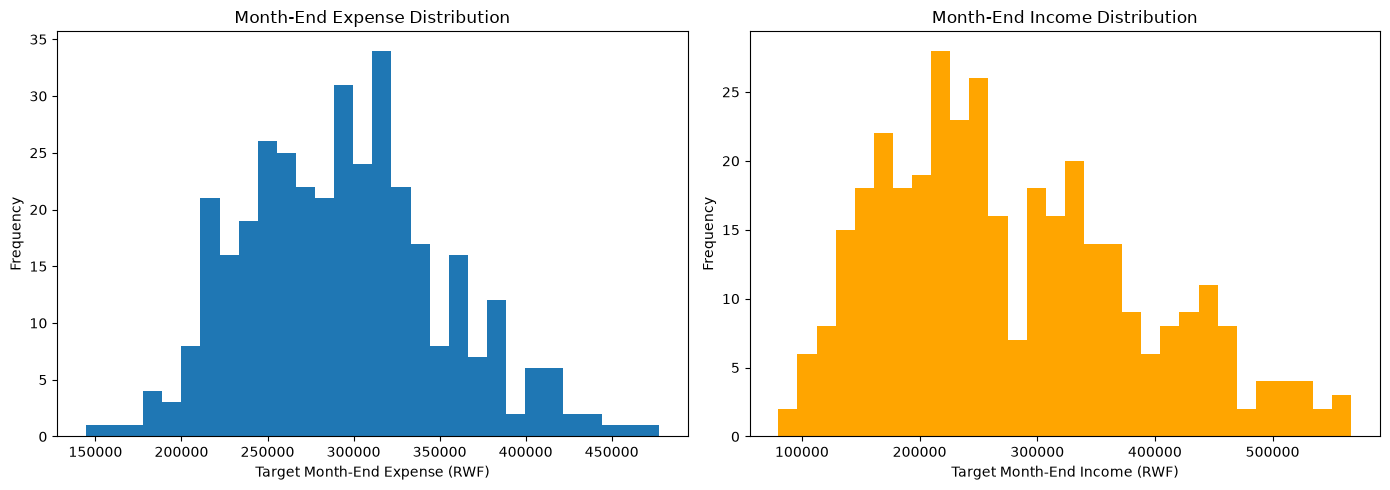

In [6]:
# 3.1 Target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pred_df[TARGET_EXPENSE].plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("Month-End Expense Distribution")
axes[0].set_xlabel("Target Month-End Expense (RWF)")
axes[0].set_ylabel("Frequency")

pred_df[TARGET_INCOME].plot(kind="hist", bins=30, ax=axes[1], color="orange")
axes[1].set_title("Month-End Income Distribution")
axes[1].set_xlabel("Target Month-End Income (RWF)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

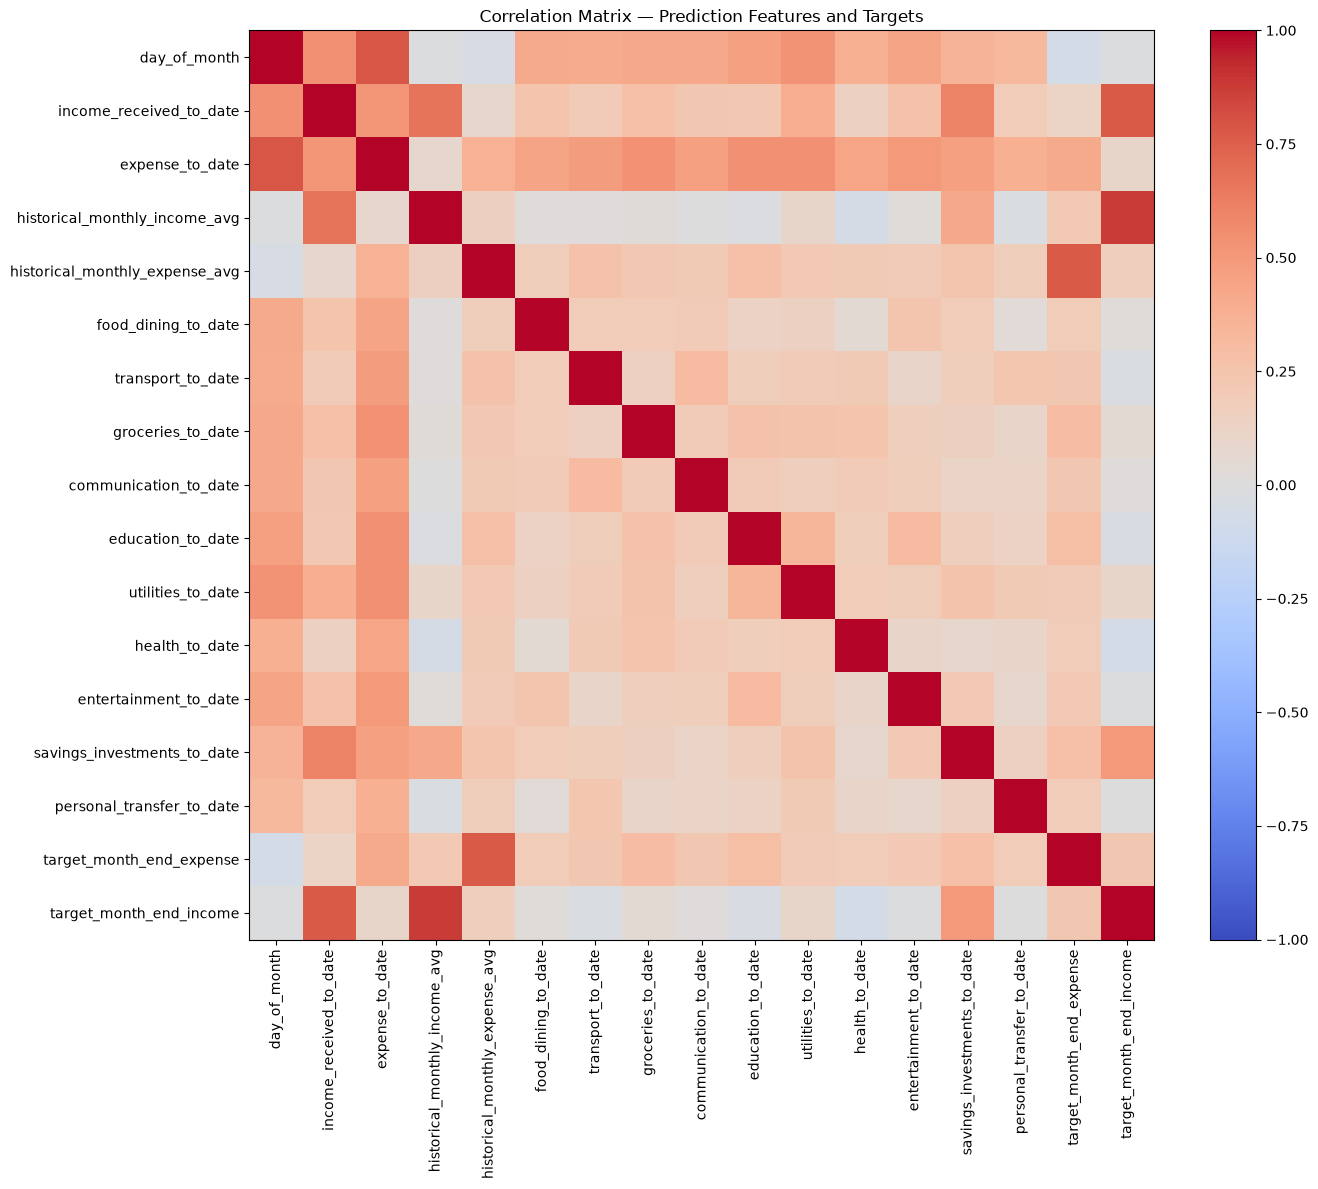

In [7]:
# 3.2 Correlation matrix
numeric_cols = PRED_FEATURES + [TARGET_EXPENSE, TARGET_INCOME]
corr = pred_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
plt.title("Correlation Matrix — Prediction Features and Targets")
plt.tight_layout()
plt.show()

,correlation_with_target_month_end_expense
historical_monthly_expense_avg,0.771458
expense_to_date,0.409025
groceries_to_date,0.293177
education_to_date,0.286439
savings_investments_to_date,0.279832
transport_to_date,0.225851
communication_to_date,0.223726
entertainment_to_date,0.208998
historical_monthly_income_avg,0.203338
utilities_to_date,0.194902


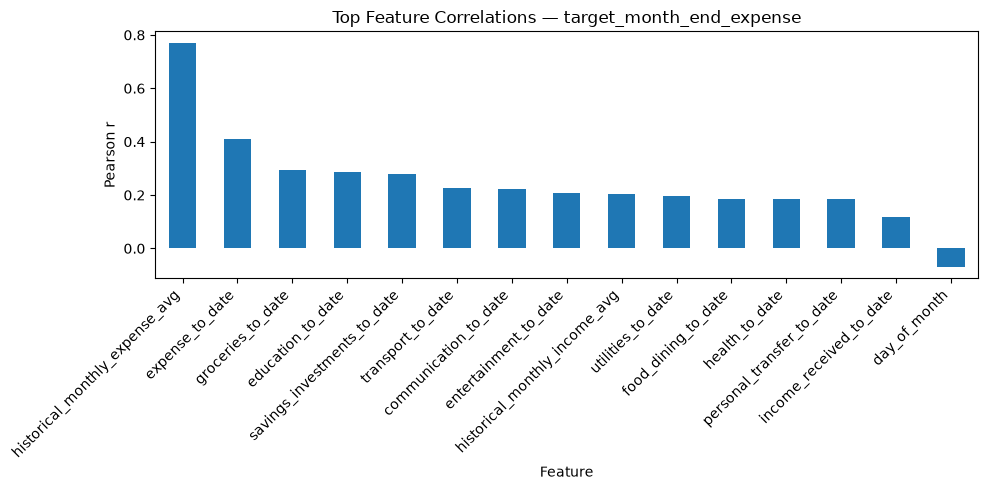

,correlation_with_target_month_end_income
historical_monthly_income_avg,0.876638
income_received_to_date,0.765960
savings_investments_to_date,0.498375
historical_monthly_expense_avg,0.162571
expense_to_date,0.096775
utilities_to_date,0.095380
health_to_date,-0.067684
groceries_to_date,0.047617
education_to_date,-0.031478
transport_to_date,-0.026318


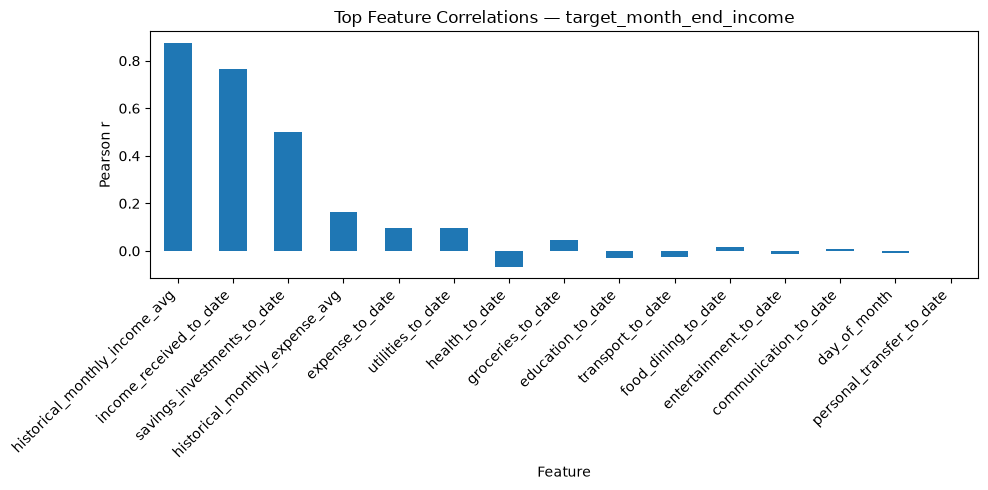

In [8]:
# 3.3 Feature-target correlation bar charts
for target in [TARGET_EXPENSE, TARGET_INCOME]:
    feat_corr = (
        corr[target]
        .drop(index=[TARGET_EXPENSE, TARGET_INCOME], errors="ignore")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    display(feat_corr.to_frame(f"correlation_with_{target}"))

    plt.figure(figsize=(10, 5))
    feat_corr.head(15).plot(kind="bar")
    plt.title(f"Top Feature Correlations — {target}")
    plt.xlabel("Feature")
    plt.ylabel("Pearson r")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

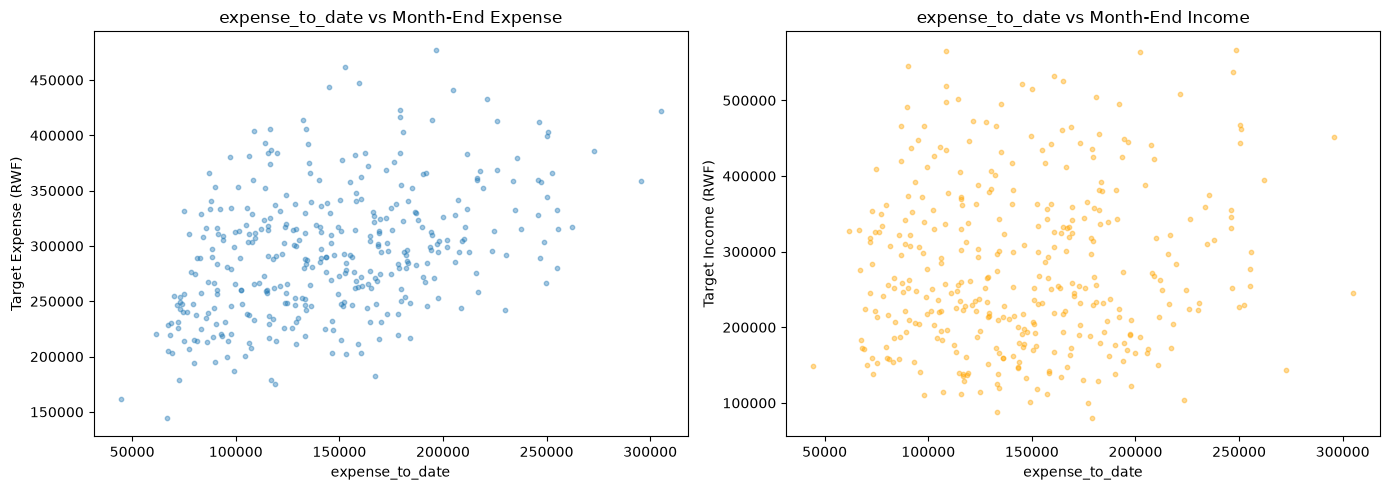

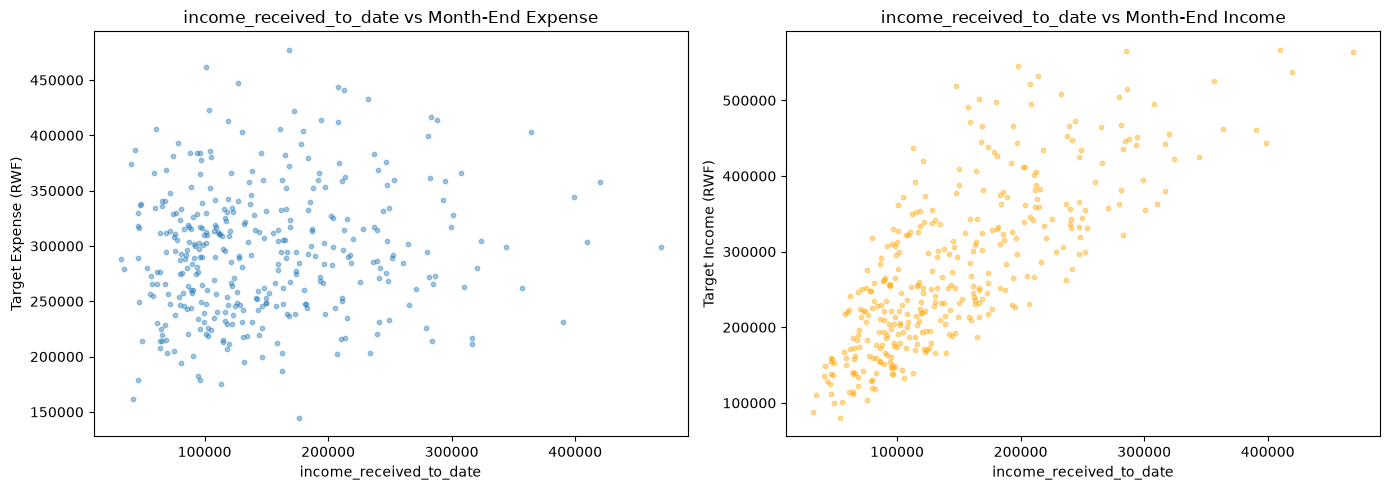

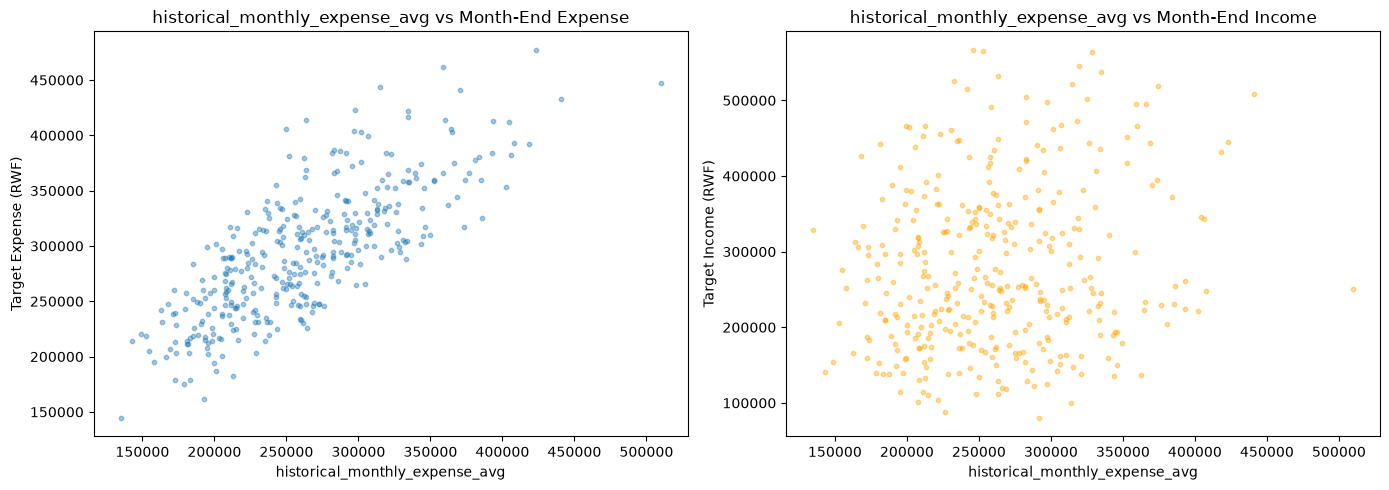

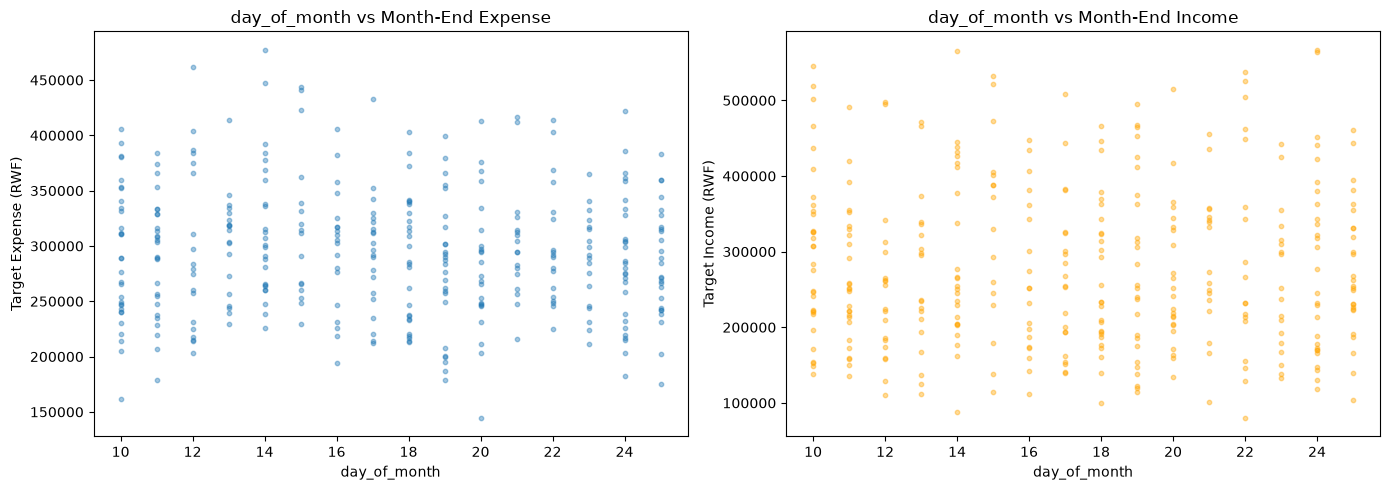

In [9]:
# 3.4 Scatter plots for key predictors vs month-end expense
key_features = [
    "expense_to_date",
    "income_received_to_date",
    "historical_monthly_expense_avg",
    "day_of_month",
]
available = [f for f in key_features if f in pred_df.columns]

for feat in available:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(pred_df[feat], pred_df[TARGET_EXPENSE], alpha=0.4, s=10)
    axes[0].set_title(f"{feat} vs Month-End Expense")
    axes[0].set_xlabel(feat)
    axes[0].set_ylabel("Target Expense (RWF)")

    axes[1].scatter(pred_df[feat], pred_df[TARGET_INCOME],
                    alpha=0.4, s=10, color="orange")
    axes[1].set_title(f"{feat} vs Month-End Income")
    axes[1].set_xlabel(feat)
    axes[1].set_ylabel("Target Income (RWF)")

    plt.tight_layout()
    plt.show()

## 4. Model Architecture

Two independent XGBoost regressors are trained — one for month-end expense,
one for month-end income. Using two separate models allows each to specialise
on its target's feature relationships.

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 150 | Sufficient trees to avoid underfitting on the synthetic scaffold |
| `max_depth` | 4 | Moderate depth; limits overfitting on a small dataset |
| `learning_rate` | 0.08 | Conservative shrinkage; combined with 150 trees |
| `subsample` | 0.8 | Row subsampling per tree; reduces variance |
| `colsample_bytree` | 0.8 | Feature subsampling per tree; reduces variance |

**Why XGBoost over linear models:** The 15 features include non-linear interactions
(e.g. spending velocity at day 25 vs day 5 has different implications). XGBoost
captures these interactions natively. See proposal Table 3.4 for the full comparison.

**Overspend risk score:** `(predicted_expense / predicted_income) × 100`, clamped to
[0, 100]. A score of 80 means 80% of predicted income is consumed by predicted
expenses. Matches the formula in `backend_api/app/services/model_service.py`.

## 5. Train and Evaluate

In [10]:
# Validate all required features are present
missing = [f for f in PRED_FEATURES if f not in pred_df.columns]
if missing:
    raise ValueError(f"Dataset is missing required features: {missing}")

X         = pred_df[PRED_FEATURES].dropna()
y_expense = pred_df.loc[X.index, TARGET_EXPENSE]
y_income  = pred_df.loc[X.index, TARGET_INCOME]

X_train, X_test, y_exp_train, y_exp_test, y_inc_train, y_inc_test = train_test_split(
    X, y_expense, y_income, test_size=0.2, random_state=42
)

xgb_params = dict(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mae",
    n_jobs=-1,
)

expense_model = XGBRegressor(**xgb_params)
income_model  = XGBRegressor(**xgb_params)

expense_model.fit(X_train, y_exp_train)
income_model.fit(X_train, y_inc_train)

exp_pred = expense_model.predict(X_test)
inc_pred = income_model.predict(X_test)


def regression_metrics(y_true, y_hat: np.ndarray) -> dict:
    rmse = float(mean_squared_error(y_true, y_hat) ** 0.5)
    return {
        "MAE":  round(float(mean_absolute_error(y_true, y_hat)), 2),
        "RMSE": round(rmse, 2),
        "R2":   round(float(r2_score(y_true, y_hat)), 4),
    }


pred_metrics = {
    "expense_model": regression_metrics(y_exp_test, exp_pred),
    "income_model":  regression_metrics(y_inc_test, inc_pred),
    "note": (
        "Trained on synthetic scaffold data. Retrain with accumulated user "
        "transaction history during the pilot for meaningful accuracy."
    ),
}
print(json.dumps(pred_metrics, indent=2))

{
  "expense_model": {
    "MAE": 26452.58,
    "RMSE": 33465.1,
    "R2": 0.6976
  },
  "income_model": {
    "MAE": 27943.52,
    "RMSE": 37220.49,
    "R2": 0.868
  },
  "note": "Trained on synthetic scaffold data. Retrain with accumulated user transaction history during the pilot for meaningful accuracy."
}


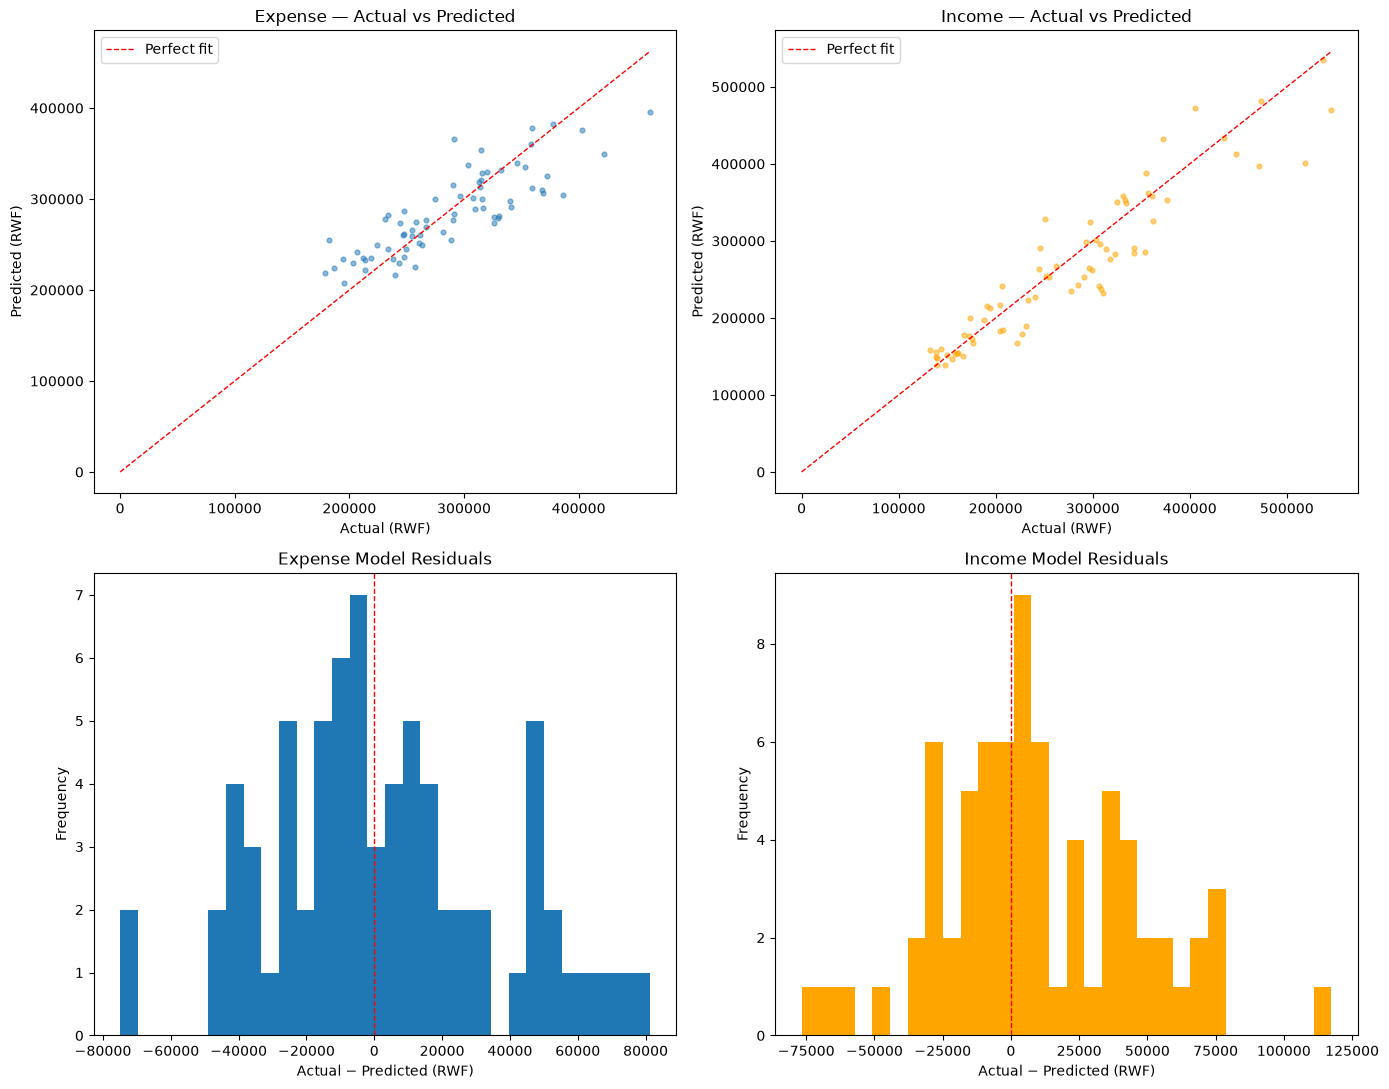

In [11]:
# 5.1 Actual vs predicted  /  5.2 Residual distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Actual vs predicted — expense
axes[0, 0].scatter(y_exp_test, exp_pred, alpha=0.5, s=12)
max_val = max(float(y_exp_test.max()), float(exp_pred.max()))
axes[0, 0].plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect fit")
axes[0, 0].set_title("Expense — Actual vs Predicted")
axes[0, 0].set_xlabel("Actual (RWF)")
axes[0, 0].set_ylabel("Predicted (RWF)")
axes[0, 0].legend()

# Actual vs predicted — income
axes[0, 1].scatter(y_inc_test, inc_pred, alpha=0.5, s=12, color="orange")
max_val = max(float(y_inc_test.max()), float(inc_pred.max()))
axes[0, 1].plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect fit")
axes[0, 1].set_title("Income — Actual vs Predicted")
axes[0, 1].set_xlabel("Actual (RWF)")
axes[0, 1].set_ylabel("Predicted (RWF)")
axes[0, 1].legend()

# Residuals
pd.Series(y_exp_test.values - exp_pred).plot(kind="hist", bins=30, ax=axes[1, 0])
axes[1, 0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1, 0].set_title("Expense Model Residuals")
axes[1, 0].set_xlabel("Actual − Predicted (RWF)")

pd.Series(y_inc_test.values - inc_pred).plot(
    kind="hist", bins=30, ax=axes[1, 1], color="orange"
)
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1, 1].set_title("Income Model Residuals")
axes[1, 1].set_xlabel("Actual − Predicted (RWF)")

plt.tight_layout()
plt.show()

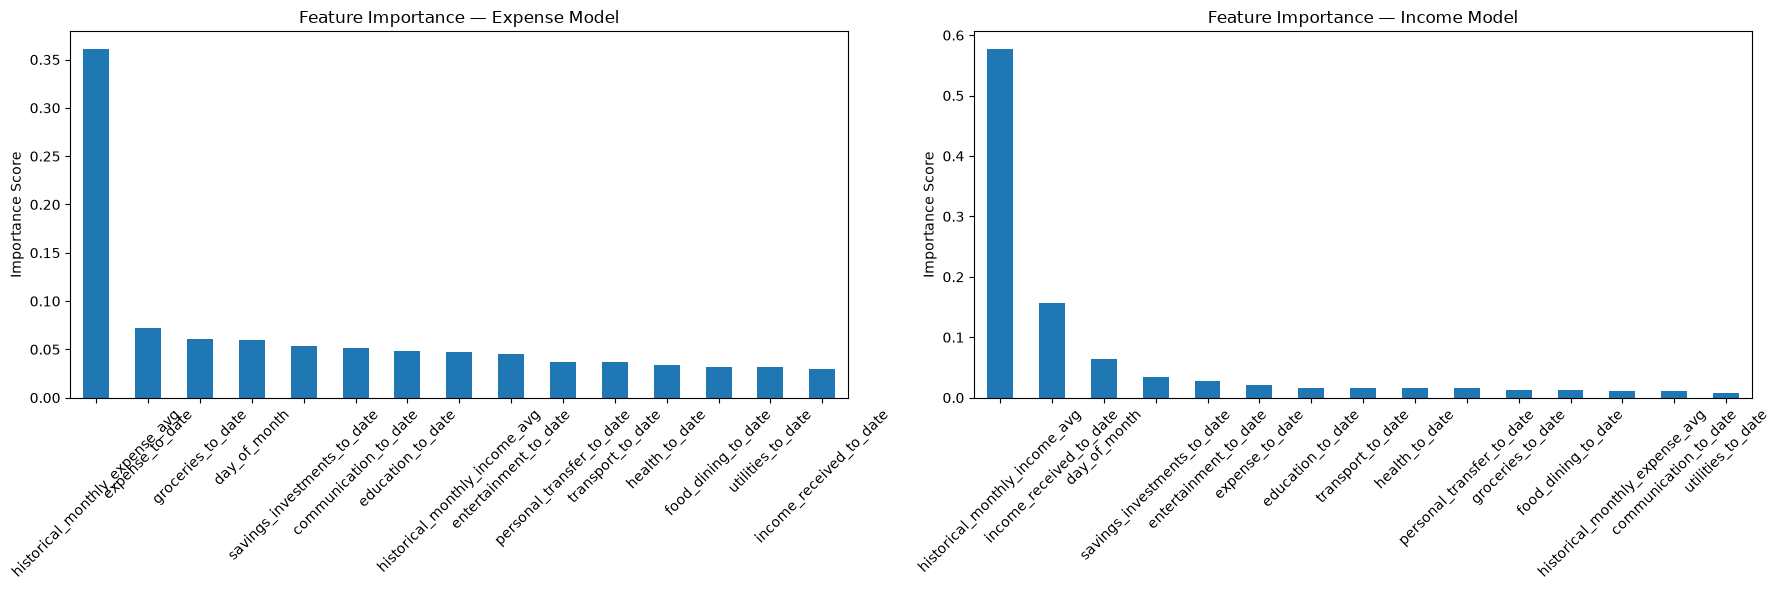

,expense_importance
historical_monthly_expense_avg,0.361193
expense_to_date,0.072296
groceries_to_date,0.061059
day_of_month,0.059495
savings_investments_to_date,0.053655
communication_to_date,0.050941
education_to_date,0.048192
historical_monthly_income_avg,0.047258
entertainment_to_date,0.045606
personal_transfer_to_date,0.036984


,income_importance
historical_monthly_income_avg,0.577479
income_received_to_date,0.156182
day_of_month,0.063537
savings_investments_to_date,0.035047
entertainment_to_date,0.027438
expense_to_date,0.021327
education_to_date,0.016560
transport_to_date,0.015892
health_to_date,0.015439
personal_transfer_to_date,0.015298


In [12]:
# 5.3 XGBoost feature importance
exp_imp = (
    pd.Series(expense_model.feature_importances_, index=PRED_FEATURES)
    .sort_values(ascending=False)
)
inc_imp = (
    pd.Series(income_model.feature_importances_, index=PRED_FEATURES)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

exp_imp.plot(kind="bar", ax=axes[0])
axes[0].set_title("Feature Importance — Expense Model")
axes[0].set_ylabel("Importance Score")
axes[0].tick_params(axis="x", rotation=45)

inc_imp.plot(kind="bar", ax=axes[1])
axes[1].set_title("Feature Importance — Income Model")
axes[1].set_ylabel("Importance Score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(exp_imp.to_frame("expense_importance"))
display(inc_imp.to_frame("income_importance"))

## 6. Overspend Risk Score

,actual_expense,predicted_expense,actual_income,predicted_income,predicted_overspend_risk
count,72.000000,72.000000,72.00000,72.000000,72.000000
mean,287332.055556,285125.218750,274550.75000,265004.875000,92.956128
std,61280.504846,45289.039062,103178.94053,97354.429688,10.768730
min,178955.000000,207746.234375,132411.00000,138608.921875,65.021477
25%,243997.250000,249574.355469,184752.50000,178592.085938,88.340773
50%,289603.500000,279573.062500,269714.50000,253321.992188,100.000000
75%,327049.000000,313909.546875,333156.25000,326281.523438,100.000000
max,462246.000000,395409.625000,546018.00000,534615.312500,100.000000


,actual_expense,predicted_expense,actual_income,predicted_income,predicted_overspend_risk
0,314557,353423.468750,405072,472647.781250,74.775230
1,307512,301266.781250,376891,353478.000000,85.229286
2,288922,254626.000000,306834,241529.421875,100.000000
3,224022,249544.203125,132411,158711.515625,100.000000
4,233562,245059.062500,161303,154468.609375,100.000000
5,368050,309974.906250,204707,216825.312500,100.000000
6,207054,241817.125000,334333,348922.437500,69.303978
7,258527,274465.750000,172166,175878.875000,100.000000
8,314881,321386.187500,356609,362018.125000,88.776276
9,239682,216854.015625,295720,265399.875000,81.708405


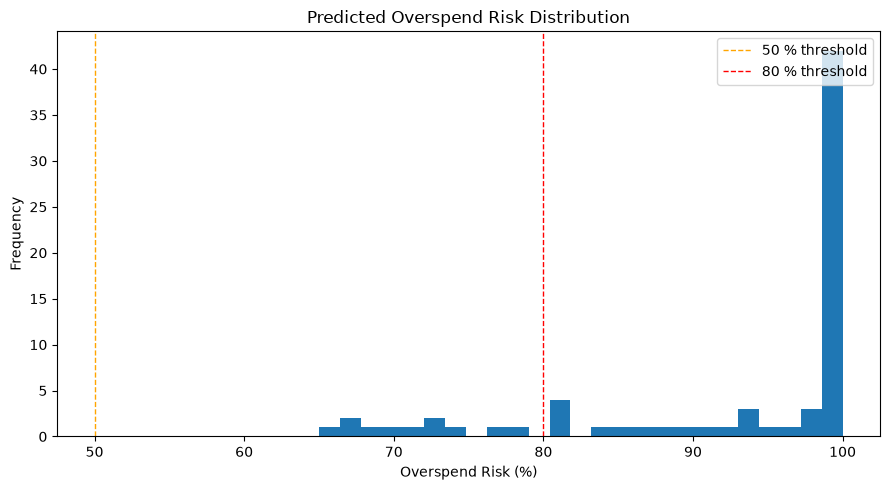

In [13]:
def calculate_overspend_risk(predicted_expense: float, predicted_income: float) -> float:
    """
    Overspend risk = (predicted_expense / predicted_income) × 100, clamped to [0, 100].
    A score of 100 means all predicted income is consumed by predicted expenses.
    Matches the formula in backend_api/app/services/model_service.py.
    """
    safe_income = max(predicted_income, 1.0)
    return float(np.clip((predicted_expense / safe_income) * 100.0, 0.0, 100.0))


risk_scores = [calculate_overspend_risk(e, i) for e, i in zip(exp_pred, inc_pred)]

risk_df = pd.DataFrame({
    "actual_expense":           y_exp_test.values,
    "predicted_expense":        exp_pred,
    "actual_income":            y_inc_test.values,
    "predicted_income":         inc_pred,
    "predicted_overspend_risk": risk_scores,
})
display(risk_df.describe())
display(risk_df.head(10))

plt.figure(figsize=(9, 5))
pd.Series(risk_scores).plot(kind="hist", bins=25)
plt.axvline(50, color="orange", linestyle="--", linewidth=1, label="50 % threshold")
plt.axvline(80, color="red",    linestyle="--", linewidth=1, label="80 % threshold")
plt.title("Predicted Overspend Risk Distribution")
plt.xlabel("Overspend Risk (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Example Inference

Demonstrates the prediction interface that mirrors
`backend_api/app/services/model_service.predict_month_end()`.

In [15]:
def predict_financial_outcome(feature_dict: dict) -> dict:
    """
    Run month-end prediction for a single user-day observation.
    Mirrors the interface of model_service.predict_month_end().
    """
    row = pd.DataFrame([{k: feature_dict.get(k, 0.0) for k in PRED_FEATURES}])
    predicted_expense = float(expense_model.predict(row)[0])
    predicted_income  = float(income_model.predict(row)[0])
    risk = calculate_overspend_risk(predicted_expense, predicted_income)
    return {
        "predicted_month_end_expense": round(max(0.0, predicted_expense), 2),
        "predicted_month_end_income":  round(max(0.0, predicted_income), 2),
        "overspend_risk_score":        round(risk, 2),
    }


example = X_test.iloc[0].to_dict()
print("Example features:")
print({k: round(v, 2) for k, v in example.items()})
print("\nPrediction:")
print(predict_financial_outcome(example))

Example features:
{'day_of_month': 15, 'income_received_to_date': 212759, 'expense_to_date': 115326, 'historical_monthly_income_avg': 404550, 'historical_monthly_expense_avg': 294969, 'food_dining_to_date': 12170, 'transport_to_date': 13917, 'groceries_to_date': 14796, 'communication_to_date': 4987, 'education_to_date': 20014, 'utilities_to_date': 4331, 'health_to_date': 13213, 'entertainment_to_date': 23397, 'savings_investments_to_date': 15051, 'personal_transfer_to_date': 14428}

Prediction:
{'predicted_month_end_expense': 353423.47, 'predicted_month_end_income': 472647.78, 'overspend_risk_score': 74.78}


## 8. Save Model Artefacts

In [16]:
expense_path = os.path.join(MODEL_OUT_DIR, "smartspend_expense_prediction_model.joblib")
income_path  = os.path.join(MODEL_OUT_DIR, "smartspend_income_prediction_model.joblib")

joblib.dump(expense_model, expense_path)
joblib.dump(income_model,  income_path)

print("Expense model saved :", expense_path)
print("Income model  saved :", income_path)

metrics_path = os.path.join(MODEL_OUT_DIR, "prediction_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(pred_metrics, f, indent=2)
print("Metrics saved       :", metrics_path)

Expense model saved : ..\backend_api\storage\models\smartspend_expense_prediction_model.joblib
Income model  saved : ..\backend_api\storage\models\smartspend_income_prediction_model.joblib
Metrics saved       : ..\backend_api\storage\models\prediction_metrics.json
